# Deep Learning HW1
## 0. Environment Setup

To ensure reproducibility, we recommend creating a dedicated conda environment before running this notebook.

### Step 1. Create a new conda environment

```bash
conda create -n dl_hw1 python=3.10 -y
conda activate dl_hw1
```
### Step 2. Install PyTorch

First try installing the GPU version:
```bash
conda install pytorch torchvision torchaudio pytorch-cuda=12.1 -c pytorch -c nvidia -y
```
If CUDA is not available on your machine, install the CPU version instead:
```bash
conda install pytorch torchvision torchaudio cpuonly -c pytorch -y
```

### Step 3. Install additional packages

```bash 
pip install numpy matplotlib tqdm jupyter
```



Environment Check
Run the following code cell to verify the environment.

In [1]:
import torch
import sys
import numpy as np

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("NumPy:", np.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

ImportError: /home/hkwon/anaconda3/envs/dl_env/lib/python3.10/site-packages/torch/lib/libtorch_cpu.so: undefined symbol: iJIT_NotifyEvent

## 1. Problem Setup and Data Preparation

In this section, we define the ordinary differential equation (ODE) considered in this assignment, its exact solution, and the default experimental setting.  
We also implement helper functions to generate training data and evaluation data.

- The random seed is fixed to `0` to ensure reproducibility.
- Training samples are generated by uniformly sampling `t` from `[0,1]`.
- The exact solution is used to construct the corresponding target values.

In [20]:
import os
import json
import math
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

import time

# ============================================================
# 기본 환경 설정
# - random seed 고정
# - device 설정
# ============================================================
def set_seed(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


# ============================================================
# 문제 설정
# - ODE: du/dt = -a u, u(0)=1
# - exact solution: u(t) = exp(-a t)
# ============================================================
A_TRUE = 2.0
N_TRAIN_DEFAULT = 20
T_MIN, T_MAX = 0.0, 1.0
EPS = 1e-12

DEFAULT_CONFIG = {
    "hidden_dim": 32,
    "depth": 1,            # hidden layer 개수
    "activation": "tanh",
    "optimizer": "Adam",
    "lr": 1e-3,
    "k_fold": 1,
    "train_size": 20,
    "n_iters": 5000,
    "seed": 0,
}

device: cuda


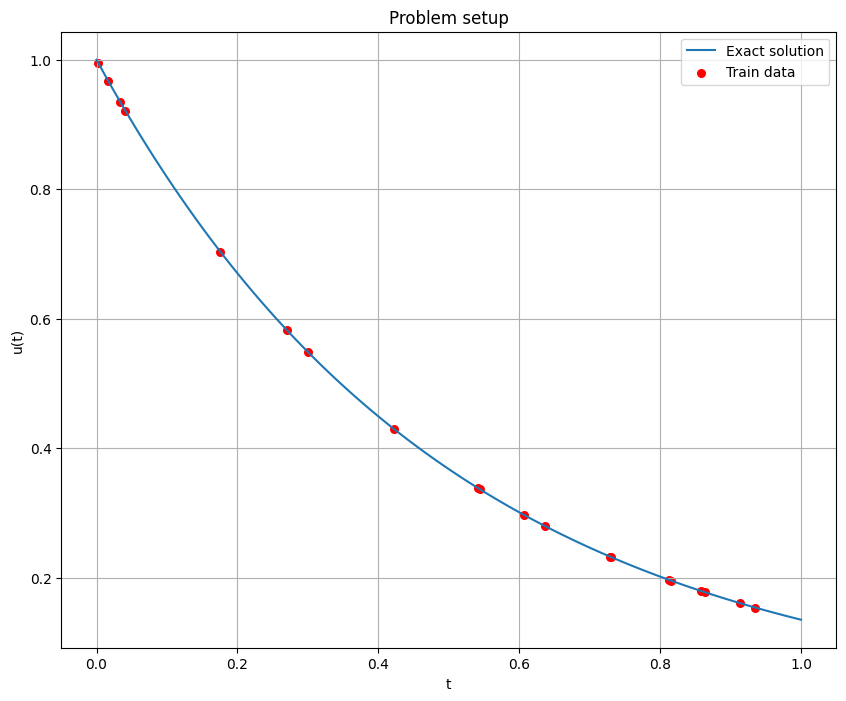

In [21]:
# ============================================================
# exact solution
# - numpy, torch 둘 다 처리 가능하게 작성
# ============================================================
def exact_solution(t, a=A_TRUE):
    if isinstance(t, np.ndarray):
        return np.exp(-a * t)
    return torch.exp(-a * t)


# ============================================================
# 데이터 생성 함수
# - train data: [0,1]에서 uniform sampling
# ============================================================
def generate_train_data(n_train=20, a=A_TRUE, t_min=T_MIN, t_max=T_MAX, seed=0):
    rng = np.random.default_rng(seed)
    t = rng.uniform(t_min, t_max, size=(n_train, 1))
    t = np.sort(t, axis=0)
    u = exact_solution(t, a=a)

    t_tensor = torch.tensor(t, dtype=torch.float32)
    u_tensor = torch.tensor(u, dtype=torch.float32)
    return t_tensor, u_tensor

def generate_eval_grid(n_eval, t_min=T_MIN, t_max=T_MAX, a=A_TRUE):
    t = np.linspace(t_min, t_max, n_eval).reshape(-1, 1)
    u = exact_solution(t, a=a)

    t_tensor = torch.tensor(t, dtype=torch.float32)
    u_tensor = torch.tensor(u, dtype=torch.float32)
    return t_tensor, u_tensor

# quick visualization
t_train, u_train = generate_train_data(n_train=N_TRAIN_DEFAULT, seed=0)
t_eval, u_eval = generate_eval_grid(n_eval = 100)

plt.figure(figsize=(10, 8))
plt.plot(t_eval.numpy(), u_eval.numpy(), label="Exact solution")
plt.scatter(t_train.numpy(), u_train.numpy(), color="red", s=30, label="Train data")
plt.xlabel("t")
plt.ylabel("u(t)")
plt.title("Problem setup")
plt.legend()
plt.grid(True)
plt.show()

## 2. Network and Training Utilities

In this section, we implement the core components required for the regression experiments.

These include:

- the MLP model,
- the optimizer builder,
- the regression loss,
- the relative \(L_2\) error,
- manual K-fold cross validation,
- and the training function.

All analyses in later sections will reuse these functions.

In [ ]:
# ============================================================
# Model
# - depth = number of hidden layers
# - depth = 0 means a linear model without hidden layers
# ============================================================
class MLP(nn.Module):
    def __init__(self, in_dim=1, hidden_dim=32, depth=1, out_dim=1, activation="tanh"):
        super().__init__()

        if activation == "tanh":
            act_layer = nn.Tanh
        elif activation == "relu":
            act_layer = nn.ReLU
        elif activation == "gelu":
            act_layer = nn.GELU
        elif activation == "sigmoid":
            act_layer = nn.Sigmoid
        else:
            raise ValueError(f"Unsupported activation: {activation}")

        # ============================================================
        # TODO:
        # Build the neural network architecture.
        #
        # Requirements:
        # 1. If depth == 0, construct a linear model:
        #       Linear(in_dim -> out_dim)
        #
        # 2. If depth >= 1, construct an MLP with:
        #       - one input layer: Linear(in_dim -> hidden_dim)
        #       - 'depth' hidden layers in total
        #       - one output layer: Linear(hidden_dim -> out_dim)
        #       - the chosen activation function after each hidden layer
        #
        # Expected behavior:
        # - depth controls the number of hidden layers
        # - hidden_dim controls the width of each hidden layer
        # ============================================================
        layers = []

        if depth == 0:
            layers.append(nn.Linear(in_dim, out_dim))
        else:
            layers.append(nn.Linear(in_dim, hidden_dim))
            layers.append(act_layer())

            for _ in range(depth - 1):
                layers.append(nn.Linear(hidden_dim, hidden_dim))
                layers.append(act_layer())

            layers.append(nn.Linear(hidden_dim, out_dim))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


In [ ]:
# ============================================================
# Optimizer
# - Build an optimizer from its name
# ============================================================
def build_optimizer(model, optimizer_name="Adam", lr=1e-3):
    # ============================================================
    # TODO:
    # Return the correct optimizer based on optimizer_name.
    #
    # Supported optimizers:
    # - "SGD"
    # - "Adam"
    # - "AdamW"
    #
    # Expected behavior:
    # - All optimizers should optimize model.parameters()
    # - The learning rate should be set by lr
    # ============================================================
    if optimizer_name == "SGD":
        return torch.optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == "Adam":
        return torch.optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == "AdamW":
        return torch.optim.AdamW(model.parameters(), lr=lr)
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")


In [ ]:
# ============================================================
# Loss and metrics
# ============================================================
def regression_loss(model, t, u):
    # ============================================================
    # TODO:
    # Compute the Mean Squared Error (MSE) loss for regression.
    #
    # Steps:
    # 1. Compute the prediction u_pred = model(t)
    # 2. Compute the MSE loss:
    #       (1/N) * sum_i (u_pred_i - u_i)^2
    #
    # Expected behavior:
    # - The returned value should be a scalar tensor
    # - This loss will be used for backpropagation
    # ============================================================
    u_pred = model(t)
    mse = torch.mean((u_pred - u) ** 2)
    return mse


In [ ]:
def relative_l2_error(u_pred, u_true, eps=EPS):
    # ============================================================
    # TODO:
    # Compute the relative L2 error:
    #
    #   ||u_pred - u_true||_2 / ||u_true||_2
    #
    # Requirements:
    # - Add eps to the denominator for numerical stability
    # ============================================================
    numerator = torch.sqrt(torch.sum((u_pred - u_true) ** 2))
    denominator = torch.sqrt(torch.sum(u_true ** 2)) + eps
    return (numerator / denominator).item()


In [ ]:
# ============================================================
# Manual K-fold split
# - Build train/validation indices without external packages
# ============================================================
def build_kfold_indices(n_samples, k=5, shuffle=True, seed=0):
    indices = np.arange(n_samples)

    if shuffle:
        rng = np.random.default_rng(seed)
        rng.shuffle(indices)

    # ============================================================
    # TODO:
    # Split the dataset indices into K folds manually.
    #
    # Steps:
    # 1. Compute the size of each fold
    # 2. For each fold:
    #    - use one part as validation indices
    #    - use the remaining parts as training indices
    # 3. Return a list of (train_idx, val_idx) pairs
    #
    # Expected behavior:
    # - The function should work even when n_samples is not divisible by k
    # - The first few folds may contain one extra sample
    # ============================================================
    fold_sizes = np.full(k, n_samples // k, dtype=int)
    fold_sizes[: n_samples % k] += 1

    folds = []
    current = 0

    for fold_size in fold_sizes:
        start = current
        end = current + fold_size

        val_idx = indices[start:end]
        train_idx = np.concatenate([indices[:start], indices[end:]])

        folds.append((train_idx, val_idx))
        current = end

    return folds

In [ ]:
# ============================================================
# 결과 저장 폴더
# - results/regression 아래에 각 설정별 폴더 생성
# ============================================================
RESULT_ROOT = Path("results/regression")
RESULT_ROOT.mkdir(parents=True, exist_ok=True)


def make_run_name(config):
    # 설정을 문자열로 만들어 폴더 이름 생성
    return (
        f"h{config['hidden_dim']}_"
        f"d{config['depth']}_"
        f"act{config['activation']}_"
        f"opt{config['optimizer']}_"
        f"lr{config['lr']}_"
        f"k{config['k_fold']}_"
        f"n{config['train_size']}_"
        f"it{config['n_iters']}_"
        f"seed{config['seed']}"
    )


# ============================================================
# Train one run
# - Train one configuration
# - Skip if the same configuration was already trained
# - Save both model parameters and summary results
# ============================================================
def train_single_run(config):
    run_name = make_run_name(config)
    run_dir = RESULT_ROOT / run_name
    run_dir.mkdir(parents=True, exist_ok=True)

    model_path = run_dir / "model.pt"
    result_path = run_dir / "result.json"

    if model_path.exists() and result_path.exists():
        print(f"[SKIP] Already trained: {run_name}")
        with open(result_path, "r", encoding="utf-8") as f:
            result = json.load(f)
        return result

    print(f"[TRAIN] Start: {run_name}")
    set_seed(config["seed"])

    t_all, u_all = generate_train_data(
        n_train=config["train_size"],
        a=A_TRUE,
        seed=config["seed"]
    )

    if config["k_fold"] == 1:
        folds = [(np.arange(len(t_all)), np.arange(len(t_all)))]
    else:
        folds = build_kfold_indices(
            n_samples=len(t_all),
            k=config["k_fold"],
            shuffle=True,
            seed=config["seed"]
        )

    fold_results = []

    for fold_id, (train_idx, val_idx) in enumerate(folds):
        t_train = t_all[train_idx].to(device)
        u_train = u_all[train_idx].to(device)
        t_val = t_all[val_idx].to(device)
        u_val = u_all[val_idx].to(device)

        model = MLP(
            hidden_dim=config["hidden_dim"],
            depth=config["depth"],
            activation=config["activation"]
        ).to(device)

        optimizer = build_optimizer(
            model,
            optimizer_name=config["optimizer"],
            lr=config["lr"]
        )

        history = {
            "iter": [],
            "train_loss": [],
            "val_loss": [],
            "val_rel_l2": [],
            "elapsed_time": [],
        }

        start_time = time.time()
        log_every = max(1, config["n_iters"] // 10)

        # ========================================================
        # TODO:
        # Implement the training loop.
        #
        # At each iteration:
        # 1. Set the model to train mode
        # 2. Clear previous gradients
        # 3. Compute the training loss
        # 4. Perform backpropagation
        # 5. Update the model parameters
        #
        # Then evaluate on the validation set:
        # 6. Set the model to eval mode
        # 7. Compute validation MSE loss
        # 8. Compute validation relative L2 error
        # 9. Store all values in history
        #
        # Logging:
        # - Print the following every n_iters // 10 iterations:
        #   [current_iter / total_iter]
        #   Train loss: ...
        #   Validation loss: ...
        #   Validation Rel L2: ...
        #   Training time: ...
        # ========================================================
        for it in range(1, config["n_iters"] + 1):
            model.train()
            optimizer.zero_grad()

            loss = regression_loss(model, t_train, u_train)
            loss.backward()
            optimizer.step()

            model.eval()
            with torch.no_grad():
                u_val_pred = model(t_val)
                val_loss = torch.mean((u_val_pred - u_val) ** 2)
                val_rel_l2 = relative_l2_error(u_val_pred, u_val)

            elapsed = time.time() - start_time

            history["iter"].append(it)
            history["train_loss"].append(loss.item())
            history["val_loss"].append(val_loss.item())
            history["val_rel_l2"].append(val_rel_l2)
            history["elapsed_time"].append(elapsed)

            if (it % log_every == 0) or (it == config["n_iters"]):
                print(
                    f"[{it}/{config['n_iters']}] "
                    f"Train loss: {loss.item():.6e}, "
                    f"Validation loss: {val_loss.item():.6e}, "
                    f"Validation Rel L2: {val_rel_l2:.6e}, "
                    f"Training time: {elapsed:.2f}s"
                )

        fold_result = {
            "fold_id": int(fold_id),
            "val_rel_l2": float(history["val_rel_l2"][-1]),
            "history": history
        }
        fold_results.append(fold_result)

    torch.save(model.state_dict(), model_path)

    result = {
        "config": config,
        "fold_results": fold_results,
        "mean_val_rel_l2": float(np.mean([fr["val_rel_l2"] for fr in fold_results])),
        "std_val_rel_l2": float(np.std([fr["val_rel_l2"] for fr in fold_results]))
    }

    with open(result_path, "w", encoding="utf-8") as f:
        json.dump(result, f, indent=2)

    print(f"[DONE] Saved to: {run_dir}")
    return result

## 3. Basic Training Run

In this section, we run a single training experiment using the default setting and check whether the full pipeline works correctly.
This step helps verify that the model, loss, optimizer, and saving procedure are implemented properly before running larger analyses.

In [29]:
# ============================================================
# Default run
# ============================================================
default_result = train_single_run(DEFAULT_CONFIG)
print(default_result["mean_val_rel_l2"], default_result["std_val_rel_l2"])

[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
0.003443556372076273 0.0


In [27]:
# ============================================================
# Example: compare K values
# ============================================================
k_list = [1, 5, N_TRAIN_DEFAULT]  # K=1, K=5, LOOCV

k_results = []
for k in k_list:
    config = DEFAULT_CONFIG.copy()
    config["k_fold"] = k
    result = train_single_run(config)
    k_results.append(result)

for result in k_results:
    print(
        f"K={result['config']['k_fold']}, "
        f"mean_rel_l2={result['mean_val_rel_l2']:.6e}, "
        f"std_rel_l2={result['std_val_rel_l2']:.6e}"
    )

[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[TRAIN] Start: h32_d1_acttanh_optAdam_lr0.001_k5_n20_it5000_seed0
[500/5000] Train loss: 4.202975e-03, Validation loss: 6.047369e-03, Validation Rel L2: 1.194664e-01, Training time: 0.60s
[1000/5000] Train loss: 3.200038e-03, Validation loss: 4.708255e-03, Validation Rel L2: 1.054126e-01, Training time: 1.15s
[1500/5000] Train loss: 1.554089e-03, Validation loss: 2.438744e-03, Validation Rel L2: 7.586573e-02, Training time: 1.69s
[2000/5000] Train loss: 2.726148e-04, Validation loss: 5.378948e-04, Validation Rel L2: 3.562962e-02, Training time: 2.23s
[2500/5000] Train loss: 1.749913e-05, Validation loss: 8.181137e-05, Validation Rel L2: 1.389535e-02, Training time: 2.76s
[3000/5000] Train loss: 5.955657e-06, Validation loss: 3.904355e-05, Validation Rel L2: 9.599247e-03, Training time: 3.32s
[3500/5000] Train loss: 4.595619e-06, Validation loss: 2.917169e-05, Validation Rel L2: 8.297425e-03, Training time: 3.88s

## 4. Analysis Utilities

In this section, we define reusable functions for loading saved results, evaluating trained models on a uniform grid, and visualizing the outputs.

These helper functions will be used in the following analyses:

- optimizer analysis,
- learning rate analysis,
- network width analysis,
- network depth analysis,
- activation function analysis,
- training data size analysis,
- and K-fold cross validation analysis.

In [30]:
# ============================================================
# Example: run multiple settings automatically
# ============================================================
optimizer_list = ["SGD", "Adam", "AdamW"]
lr_list = [1e-2, 1e-3, 1e-4]
hidden_dims = [4, 16, 32, 64]
depths = [0, 1, 2]
activations = ["tanh", "relu", "sigmoid"]

all_results = []

# optimizer sweep
for opt_name in optimizer_list:
    config = DEFAULT_CONFIG.copy()
    config["optimizer"] = opt_name
    result = train_single_run(config)
    all_results.append(result)

# learning rate sweep
for lr in lr_list:
    config = DEFAULT_CONFIG.copy()
    config["lr"] = lr
    result = train_single_run(config)
    all_results.append(result)

# hidden width sweep
for h in hidden_dims:
    config = DEFAULT_CONFIG.copy()
    config["hidden_dim"] = h
    result = train_single_run(config)
    all_results.append(result)

# depth sweep
for d in depths:
    config = DEFAULT_CONFIG.copy()
    config["depth"] = d
    result = train_single_run(config)
    all_results.append(result)

# activation sweep
for act in activations:
    config = DEFAULT_CONFIG.copy()
    config["activation"] = act
    result = train_single_run(config)
    all_results.append(result)

# training data size sweep
for n in [5, 10, 20, 50, 100]:
    config = DEFAULT_CONFIG.copy()
    config["train_size"] = n
    result = train_single_run(config)
    all_results.append(result)

[TRAIN] Start: h32_d1_acttanh_optSGD_lr0.001_k1_n20_it5000_seed0
[500/5000] Train loss: 2.745113e-02, Validation loss: 2.740736e-02, Validation Rel L2: 3.111183e-01, Training time: 0.47s
[1000/5000] Train loss: 1.328000e-02, Validation loss: 1.326305e-02, Validation Rel L2: 2.164281e-01, Training time: 0.97s
[1500/5000] Train loss: 7.831330e-03, Validation loss: 7.824874e-03, Validation Rel L2: 1.662382e-01, Training time: 1.45s
[2000/5000] Train loss: 5.764004e-03, Validation loss: 5.761564e-03, Validation Rel L2: 1.426469e-01, Training time: 1.90s
[2500/5000] Train loss: 4.982549e-03, Validation loss: 4.981618e-03, Validation Rel L2: 1.326408e-01, Training time: 2.34s
[3000/5000] Train loss: 4.683217e-03, Validation loss: 4.682853e-03, Validation Rel L2: 1.286019e-01, Training time: 2.79s
[3500/5000] Train loss: 4.562991e-03, Validation loss: 4.562839e-03, Validation Rel L2: 1.269432e-01, Training time: 3.24s
[4000/5000] Train loss: 4.508923e-03, Validation loss: 4.508850e-03, Valida

## 5. Hyperparameter Analysis

In this section, we compare the training dynamics and prediction accuracy under different hyperparameter settings.

For each analysis, we visualize:

- the training loss curve,
- the prediction together with the exact solution,
- the pointwise relative error,
- and the relative $L_2$ error.

In [33]:
# ============================================================
# 결과 불러오기
# ============================================================
def load_result(config):
    run_name = make_run_name(config)
    run_dir = RESULT_ROOT / run_name
    result_path = run_dir / "result.json"
    model_path = run_dir / "model.pt"

    if not result_path.exists():
        raise FileNotFoundError(f"Result file not found: {result_path}")
    if not model_path.exists():
        raise FileNotFoundError(f"Model file not found: {model_path}")

    with open(result_path, "r", encoding="utf-8") as f:
        result = json.load(f)

    model = MLP(
        hidden_dim=config["hidden_dim"],
        depth=config["depth"],
        activation=config["activation"]
    ).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    return result, model


# ============================================================
# evaluation data 생성
# - Analysis에서는 [0,1] 구간의 uniform grid 사용
# ============================================================
def generate_analysis_grid(n_eval=200, t_min=T_MIN, t_max=T_MAX, a=A_TRUE):
    t = np.linspace(t_min, t_max, n_eval).reshape(-1, 1)
    u = exact_solution(t, a=a)

    t_tensor = torch.tensor(t, dtype=torch.float32).to(device)
    u_tensor = torch.tensor(u, dtype=torch.float32).to(device)
    return t_tensor, u_tensor


# ============================================================
# 모델 예측과 error 계산
# ============================================================
def evaluate_model_on_grid(model, n_eval=200):
    t_grid, u_exact = generate_analysis_grid(n_eval=n_eval)

    with torch.no_grad():
        u_pred = model(t_grid)

    rel_l2 = relative_l2_error(u_pred, u_exact)
    pw_rel = pointwise_relative_error(u_pred, u_exact).detach().cpu().numpy()

    return {
        "t": t_grid.detach().cpu().numpy(),
        "u_exact": u_exact.detach().cpu().numpy(),
        "u_pred": u_pred.detach().cpu().numpy(),
        "pointwise_rel_error": pw_rel,
        "relative_l2": rel_l2
    }

#### 3.2 공통 Plot 함수
여러 설정을 한 번에 비교할 수 있도록 공통 plotting 함수를 정의한다. 겹치는 선들도 비교 가능하도록 linewidth와 alpha를 조절한다.

In [34]:
# ============================================================
# 공통 plot style
# ============================================================
DEFAULT_LINEWIDTH = 2.0
DEFAULT_ALPHA = 0.75
EXACT_LINEWIDTH = 3.0
EXACT_ALPHA = 0.9


# ============================================================
# Training loss plot
# ============================================================
def plot_training_loss_comparison(results_dict, title="Training Loss Comparison"):
    plt.figure(figsize=(7, 4))

    for label, result in results_dict.items():
        history = result["fold_results"][0]["history"]
        plt.plot(
            history["iter"],
            history["train_loss"],
            label=label,
            linewidth=DEFAULT_LINEWIDTH,
            alpha=DEFAULT_ALPHA
        )

    plt.yscale("log")
    plt.xlabel("Iteration")
    plt.ylabel("Training Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


# ============================================================
# Prediction vs exact plot
# ============================================================
def plot_prediction_vs_exact(eval_dict, title="Prediction vs Exact"):
    plt.figure(figsize=(7, 4))

    # exact solution 먼저 그림
    first_key = list(eval_dict.keys())[0]
    plt.plot(
        eval_dict[first_key]["t"],
        eval_dict[first_key]["u_exact"],
        label="Exact",
        linewidth=EXACT_LINEWIDTH,
        alpha=EXACT_ALPHA,
        color="black"
    )

    # 각 설정별 prediction
    for label, out in eval_dict.items():
        plt.plot(
            out["t"],
            out["u_pred"],
            label=label,
            linewidth=DEFAULT_LINEWIDTH,
            alpha=DEFAULT_ALPHA
        )

    plt.xlabel("t")
    plt.ylabel("u(t)")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


# ============================================================
# Pointwise relative error plot
# ============================================================
def plot_pointwise_relative_error(eval_dict, title="Pointwise Relative Error"):
    plt.figure(figsize=(7, 4))

    for label, out in eval_dict.items():
        plt.plot(
            out["t"],
            out["pointwise_rel_error"],
            label=label,
            linewidth=DEFAULT_LINEWIDTH,
            alpha=DEFAULT_ALPHA
        )

    plt.xlabel("t")
    plt.ylabel("Pointwise Relative Error")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


# ============================================================
# Relative L2 bar plot
# ============================================================
def plot_relative_l2_bar(eval_dict, title="Relative L2 Error"):
    labels = list(eval_dict.keys())
    values = [eval_dict[label]["relative_l2"] for label in labels]

    plt.figure(figsize=(7, 4))
    plt.bar(labels, values, alpha=0.8)
    plt.ylabel("Relative L2 Error")
    plt.title(title)
    plt.grid(True, axis="y")
    plt.show()


# ============================================================
# Relative L2 value print
# ============================================================
def print_relative_l2_table(eval_dict):
    print(f"{'Setting':<20} {'Relative L2 Error':<20}")
    print("-" * 40)
    for label, out in eval_dict.items():
        print(f"{label:<20} {out['relative_l2']:<20.6e}")

#### 4. Hyperparameter Analysis
##### 4.1 Optimizer Analysis
optimizer를 바꾸었을 때 training loss, pointwise relative error, relative L2 error, prediction curve가 어떻게 달라지는지 비교한다

[SKIP] Already trained: h32_d1_acttanh_optSGD_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d1_acttanh_optAdamW_lr0.001_k1_n20_it5000_seed0


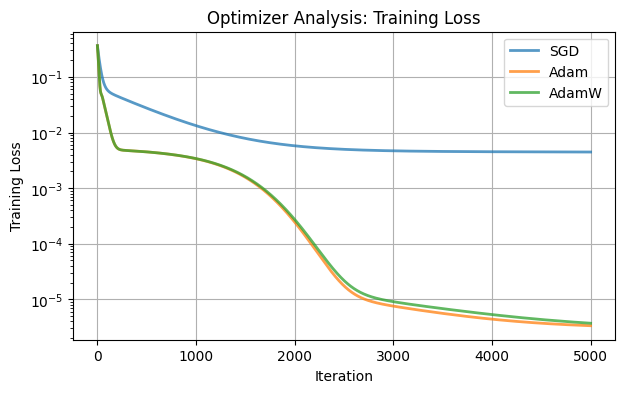

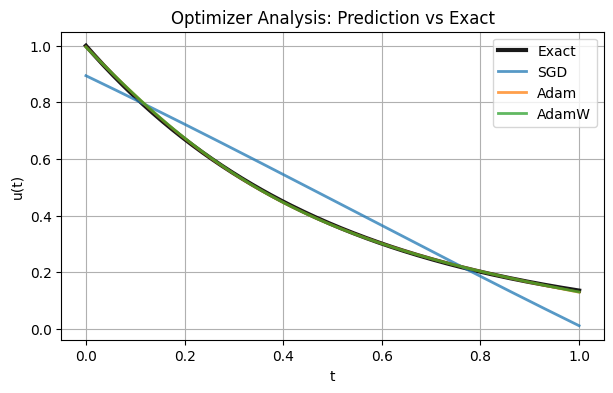

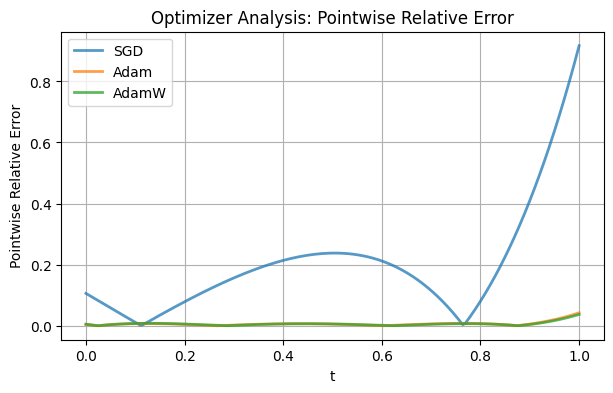

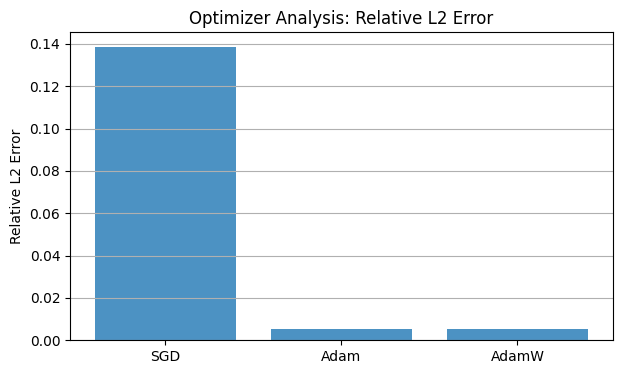

Setting              Relative L2 Error   
----------------------------------------
SGD                  1.385799e-01        
Adam                 5.291088e-03        
AdamW                5.495466e-03        


In [ ]:
# ============================================================
# Optimizer Analysis
# ============================================================
optimizer_list = ["SGD", "Adam", "AdamW"]
optimizer_results = {}
optimizer_eval = {}

for opt_name in optimizer_list:
    config = DEFAULT_CONFIG.copy()
    config["optimizer"] = opt_name

    result = train_single_run(config)
    loaded_result, model = load_result(config)
    eval_out = evaluate_model_on_grid(model)

    optimizer_results[opt_name] = loaded_result
    optimizer_eval[opt_name] = eval_out

plot_training_loss_comparison(optimizer_results,title="Optimizer Analysis: Training Loss")
plot_prediction_vs_exact(optimizer_eval,title="Optimizer Analysis: Prediction vs Exact")
plot_pointwise_relative_error(optimizer_eval,title="Optimizer Analysis: Pointwise Relative Error")
plot_relative_l2_bar(optimizer_eval,title="Optimizer Analysis: Relative L2 Error")
print_relative_l2_table(optimizer_eval)

##### 4.2 Learning Rate Analysis
learning rate 변화에 따른 training dynamics와 prediction accuracy를 비교한다

[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.01_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.0001_k1_n20_it5000_seed0


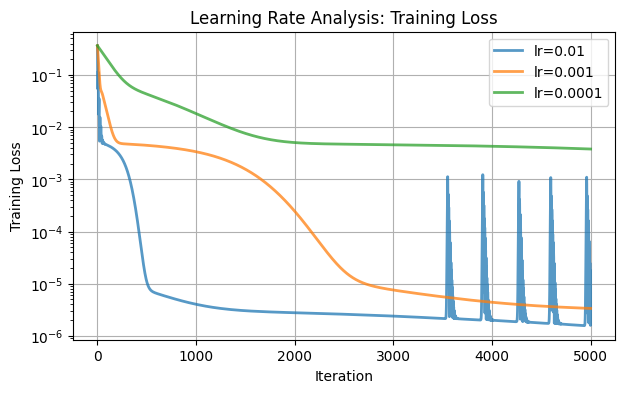

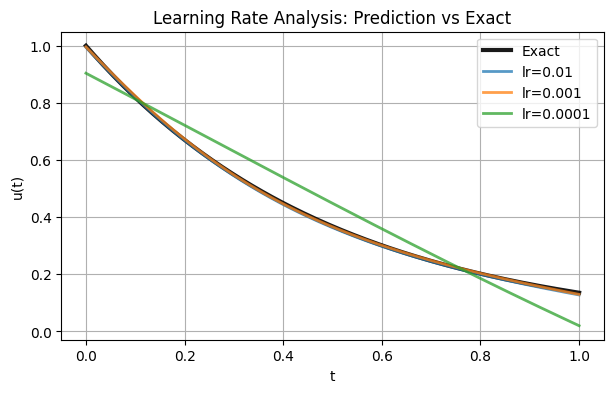

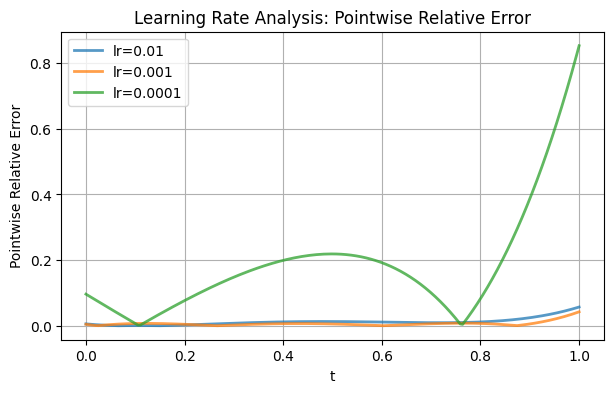

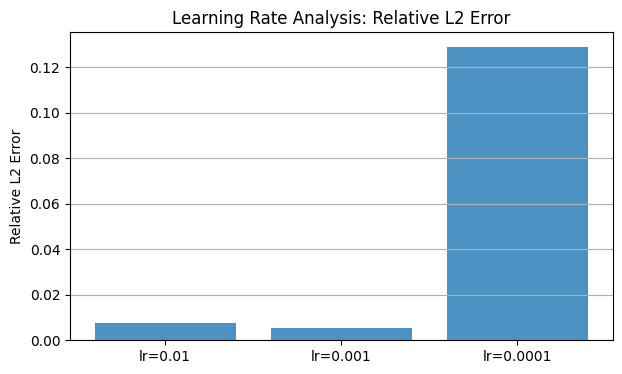

Setting              Relative L2 Error   
----------------------------------------
lr=0.01              7.505275e-03        
lr=0.001             5.291088e-03        
lr=0.0001            1.289164e-01        


In [36]:
# ============================================================
# Learning Rate Analysis
# ============================================================
lr_list = [1e-2, 1e-3, 1e-4]

lr_results = {}
lr_eval = {}

for lr in lr_list:
    config = DEFAULT_CONFIG.copy()
    config["lr"] = lr

    result = train_single_run(config)
    loaded_result, model = load_result(config)
    eval_out = evaluate_model_on_grid(model)

    label = f"lr={lr}"
    lr_results[label] = loaded_result
    lr_eval[label] = eval_out

plot_training_loss_comparison(
    lr_results,
    title="Learning Rate Analysis: Training Loss"
)

plot_prediction_vs_exact(
    lr_eval,
    title="Learning Rate Analysis: Prediction vs Exact"
)

plot_pointwise_relative_error(
    lr_eval,
    title="Learning Rate Analysis: Pointwise Relative Error"
)

plot_relative_l2_bar(
    lr_eval,
    title="Learning Rate Analysis: Relative L2 Error"
)

print_relative_l2_table(lr_eval)

##### 4.3 Network Width Analysis
hidden width를 4, 16, 32, 64로 바꾸면서 network capacity가 결과에 미치는 영향을 비교한다.

[SKIP] Already trained: h4_d1_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h16_d1_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h64_d1_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0


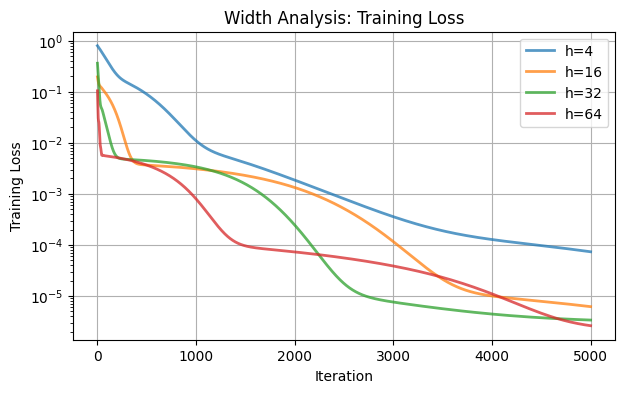

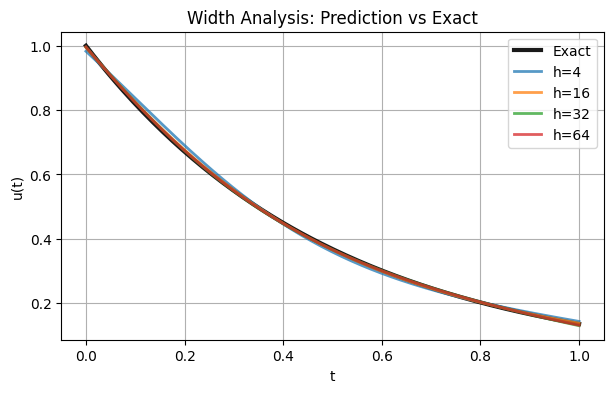

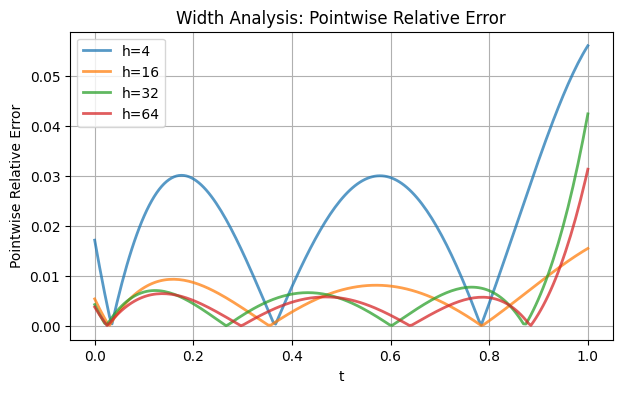

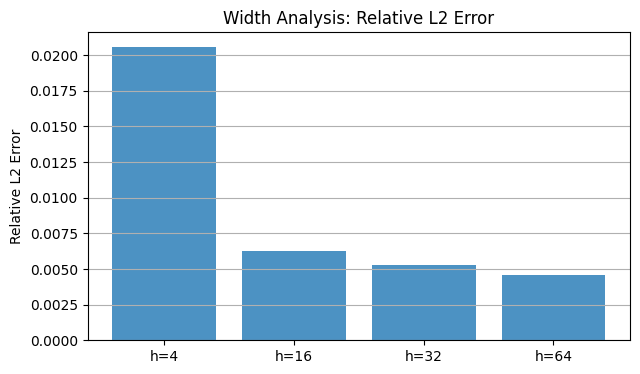

Setting              Relative L2 Error   
----------------------------------------
h=4                  2.057500e-02        
h=16                 6.264667e-03        
h=32                 5.291088e-03        
h=64                 4.559055e-03        


In [38]:
# ============================================================
# Network Width Analysis
# ============================================================
width_list = [4, 16, 32, 64]

width_results = {}
width_eval = {}

for h in width_list:
    config = DEFAULT_CONFIG.copy()
    config["hidden_dim"] = h

    result = train_single_run(config)
    loaded_result, model = load_result(config)
    eval_out = evaluate_model_on_grid(model)

    label = f"h={h}"
    width_results[label] = loaded_result
    width_eval[label] = eval_out

plot_training_loss_comparison(
    width_results,
    title="Width Analysis: Training Loss"
)

plot_prediction_vs_exact(
    width_eval,
    title="Width Analysis: Prediction vs Exact"
)

plot_pointwise_relative_error(
    width_eval,
    title="Width Analysis: Pointwise Relative Error"
)

plot_relative_l2_bar(
    width_eval,
    title="Width Analysis: Relative L2 Error"
)

print_relative_l2_table(width_eval)

##### 4.4 Network Depth Analysis
hidden layer 개수(depth)를 0, 1, 2로 바꾸면서 network depth의 효과를 비교한다. depth=0은 hidden layer 없는 linear model이다

[SKIP] Already trained: h32_d0_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d2_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0


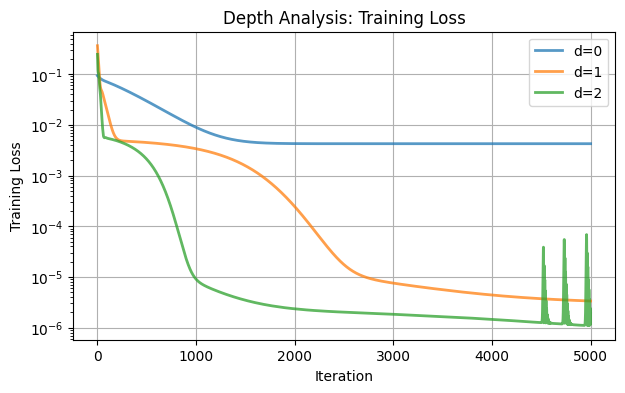

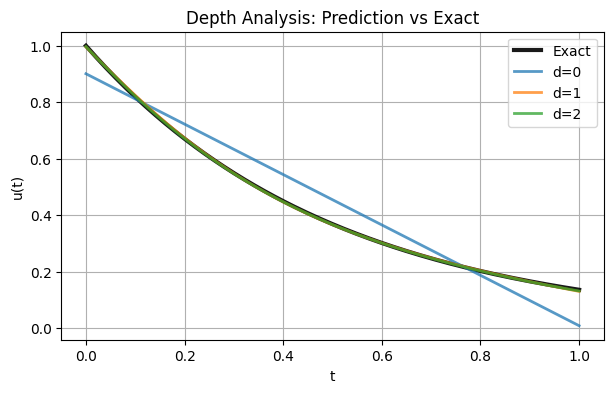

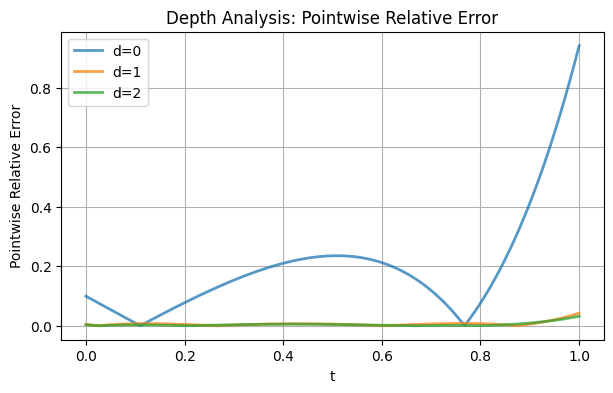

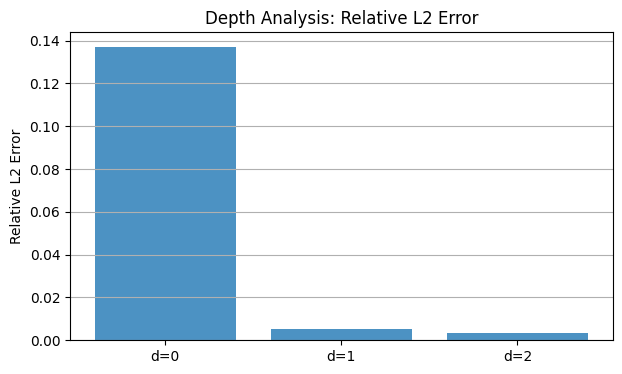

Setting              Relative L2 Error   
----------------------------------------
d=0                  1.370402e-01        
d=1                  5.291088e-03        
d=2                  3.319287e-03        


In [40]:
# ============================================================
# Network Depth Analysis
# ============================================================
depth_list = [0, 1, 2]

depth_results = {}
depth_eval = {}

for d in depth_list:
    config = DEFAULT_CONFIG.copy()
    config["depth"] = d

    result = train_single_run(config)
    loaded_result, model = load_result(config)
    eval_out = evaluate_model_on_grid(model)

    label = f"d={d}"
    depth_results[label] = loaded_result
    depth_eval[label] = eval_out

plot_training_loss_comparison(
    depth_results,
    title="Depth Analysis: Training Loss"
)

plot_prediction_vs_exact(
    depth_eval,
    title="Depth Analysis: Prediction vs Exact"
)

plot_pointwise_relative_error(
    depth_eval,
    title="Depth Analysis: Pointwise Relative Error"
)

plot_relative_l2_bar(
    depth_eval,
    title="Depth Analysis: Relative L2 Error"
)

print_relative_l2_table(depth_eval)

##### 4.5 Activation function analysis
activation function을 바꾸면서 training dynamics와 prediction accuracy를 비교한다

[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d1_actrelu_optAdam_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d1_actsigmoid_optAdam_lr0.001_k1_n20_it5000_seed0


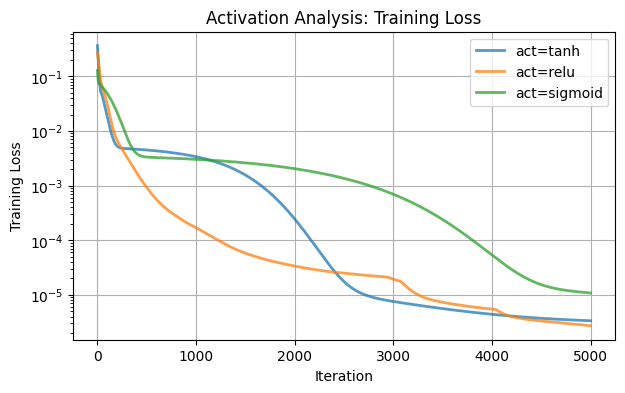

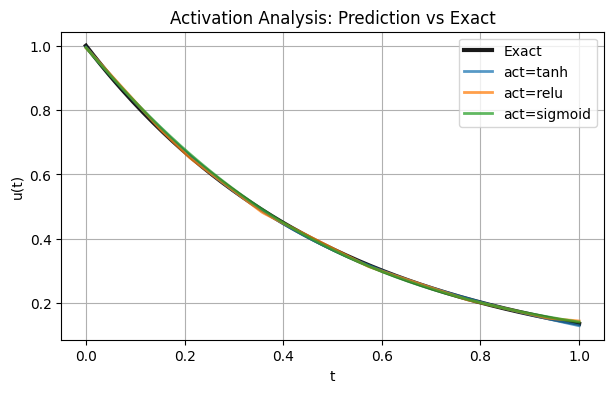

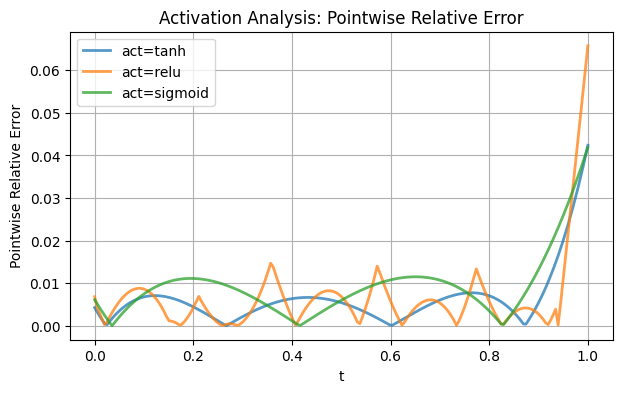

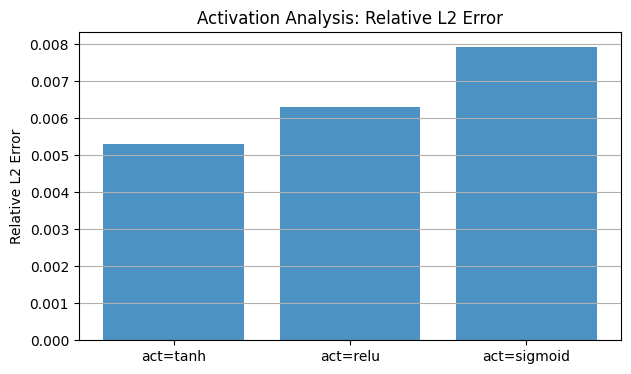

Setting              Relative L2 Error   
----------------------------------------
act=tanh             5.291088e-03        
act=relu             6.307792e-03        
act=sigmoid          7.919482e-03        


In [41]:
# ============================================================
# Activation Function Analysis
# ============================================================
activation_list = ["tanh", "relu", "sigmoid"]

act_results = {}
act_eval = {}

for act in activation_list:
    config = DEFAULT_CONFIG.copy()
    config["activation"] = act

    result = train_single_run(config)
    loaded_result, model = load_result(config)
    eval_out = evaluate_model_on_grid(model)

    label = f"act={act}"
    act_results[label] = loaded_result
    act_eval[label] = eval_out

plot_training_loss_comparison(
    act_results,
    title="Activation Analysis: Training Loss"
)

plot_prediction_vs_exact(
    act_eval,
    title="Activation Analysis: Prediction vs Exact"
)

plot_pointwise_relative_error(
    act_eval,
    title="Activation Analysis: Pointwise Relative Error"
)

plot_relative_l2_bar(
    act_eval,
    title="Activation Analysis: Relative L2 Error"
)

print_relative_l2_table(act_eval)

## 6. K-Fold Cross Validation

In this section, we compare three validation settings:

- K = 1,
- K = 5,
- and Leave-One-Out Cross Validation (LOOCV).

The goal is to examine how the validation strategy affects the estimated model performance when the number of training samples is limited.

[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_k1_n20_it5000_seed0
[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_k5_n20_it5000_seed0
[SKIP] Already trained: h32_d1_acttanh_optAdam_lr0.001_k20_n20_it5000_seed0


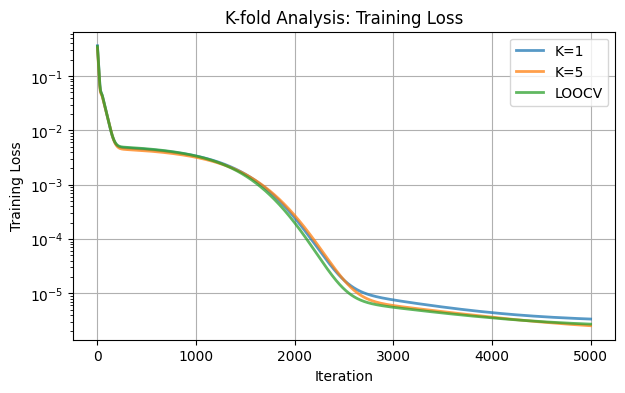

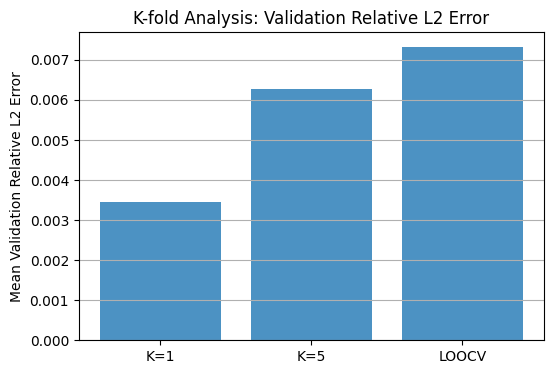

Setting              Mean Rel L2          Std Rel L2          
------------------------------------------------------------
K=1                  3.443556e-03         0.000000e+00        
K=5                  6.278952e-03         2.152727e-03        
LOOCV                7.323046e-03         8.732820e-03        


In [ ]:
# ============================================================
# K-fold Cross Validation Analysis
# ============================================================
k_list = [1, 5, DEFAULT_CONFIG["train_size"]]   # K=1, K=5, LOOCV

cv_results = {}

for k in k_list:
    config = DEFAULT_CONFIG.copy()
    config["k_fold"] = k

    result = train_single_run(config)
    label = "LOOCV" if k == DEFAULT_CONFIG["train_size"] else f"K={k}"
    cv_results[label] = result



# training loss comparison
plot_training_loss_comparison(
    cv_results,
    title="K-fold Analysis: Training Loss"
)

# relative L2 comparison
labels = list(cv_results.keys())
values = [cv_results[label]["mean_val_rel_l2"] for label in labels]

plt.figure(figsize=(6, 4))
plt.bar(labels, values, alpha=0.8)
plt.ylabel("Mean Validation Relative L2 Error")
plt.title("K-fold Analysis: Validation Relative L2 Error")
plt.grid(True, axis="y")
plt.show()

print(f"{'Setting':<20} {'Mean Rel L2':<20} {'Std Rel L2':<20}")
print("-" * 60)
for label, result in cv_results.items():
    print(
        f"{label:<20} "
        f"{result['mean_val_rel_l2']:<20.6e} "
        f"{result['std_val_rel_l2']:<20.6e}"
    )